# Resampling — Cross-Validation and the Bootstrap


We almost never know test error directly.
Instead we **hold parts of the training set out**, refit, and measure error on the held-out pieces. Two families of methods:

| Method | What it estimates | Cost |
|---|---|---|
| Validation set | Test MSE (Mean Squared Error) — single estimate, high variance | 1 fit |
| LOOCV (Leave-One-Out Cross-Validation) | Test MSE (low variance, can be high cost) | $n$ fits |
| $k$-fold CV (Cross-Validation) | Test MSE (good bias/variance balance) | $k$ fits |
| Bootstrap | Sampling distribution of any statistic | $B$ fits |

## The picture — k-fold cross-validation partitions data into rotating train/test

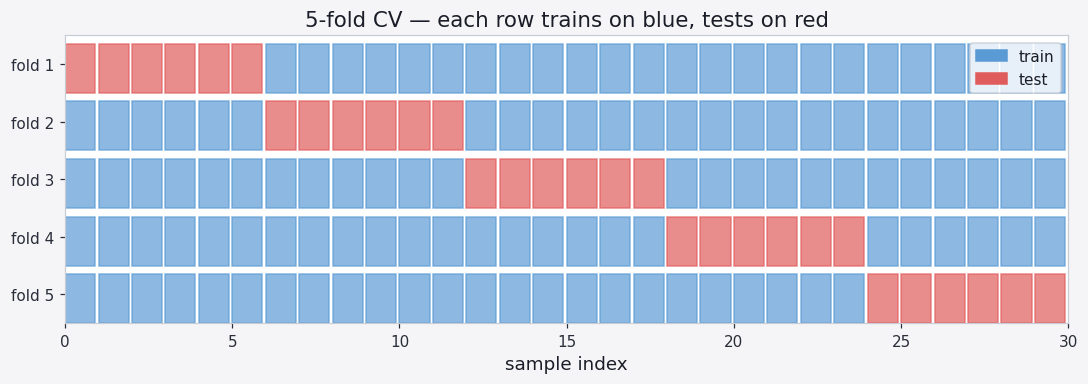

In [5]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
K = 5; n = 30
fig, ax = plt.subplots(figsize=(10, 3.6))
for k in range(K):
    test_start = k * n // K; test_end = (k+1) * n // K
    for i in range(n):
        c = P[1] if test_start <= i < test_end else P[0]
        ax.add_patch(Rectangle((i, K-1-k), 0.9, 0.85, color=c, alpha=0.7))
ax.set_xlim(0, n); ax.set_ylim(0, K)
ax.set_yticks(np.arange(K)+0.5); ax.set_yticklabels([f'fold {K-k}' for k in range(K)])
ax.set_xlabel('sample index')
ax.set_title('5-fold CV — each row trains on blue, tests on red')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=P[0], label='train'), Patch(color=P[1], label='test')],
          loc='upper right')
plt.tight_layout(); plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, LeaveOneOut, train_test_split

rng = np.random.RandomState(0)
n = 100
X = rng.uniform(-3, 3, n)
y = np.sin(X) + 0.4*rng.randn(n)
X = X[:, None]
print('Synthetic regression set:', X.shape, y.shape)


Synthetic regression set: (100, 1) (100,)


---
## 1. Validation set vs $k$-fold CV vs LOOCV

We sweep polynomial degree from 1 to 12 and compare three test-error estimates.


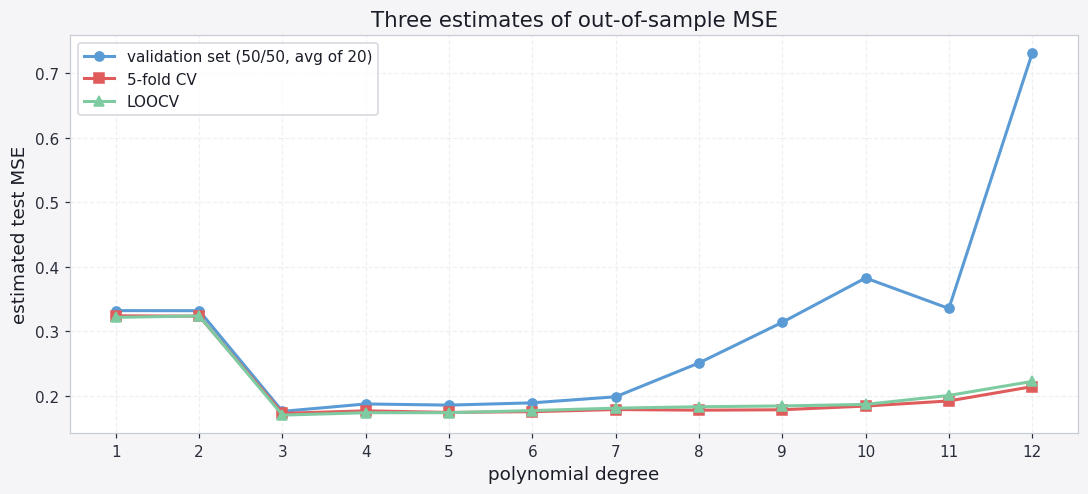

Best degree by CV: 3


In [7]:
degs = list(range(1, 13))
val, kf5, loocv = [], [], []
n_repeats = 20

for d in degs:
    # Validation set (50/50)
    scores = []
    for r in range(n_repeats):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.5, random_state=r)
        m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(Xtr, ytr)
        scores.append(np.mean((yte - m.predict(Xte))**2))
    val.append(np.mean(scores))

    # k-fold CV
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    s = []
    for tr, te in kf.split(X):
        m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X[tr], y[tr])
        s.append(np.mean((y[te] - m.predict(X[te]))**2))
    kf5.append(np.mean(s))

    # LOOCV
    loo = LeaveOneOut()
    s = []
    for tr, te in loo.split(X):
        m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X[tr], y[tr])
        s.append((y[te[0]] - m.predict(X[te])[0])**2)
    loocv.append(np.mean(s))

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(degs, val,   color=PALETTE[0], lw=2, marker='o', label='validation set (50/50, avg of 20)')
ax.plot(degs, kf5,   color=PALETTE[1], lw=2, marker='s', label='5-fold CV')
ax.plot(degs, loocv, color=PALETTE[3], lw=2, marker='^', label='LOOCV')
ax.set_xlabel('polynomial degree'); ax.set_ylabel('estimated test MSE')
ax.set_title('Three estimates of out-of-sample MSE')
ax.set_xticks(degs); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()
print('Best degree by CV:', degs[int(np.argmin(kf5))])


---
## 2. The bootstrap — confidence intervals for *any* statistic

We have a sample $\{x_1, \dots, x_n\}$ and want a CI (Confidence Interval) for some statistic $\hat\theta$ (here, the **median**).
Resample with replacement $B$ times, recompute, take the empirical 2.5/97.5 percentiles.

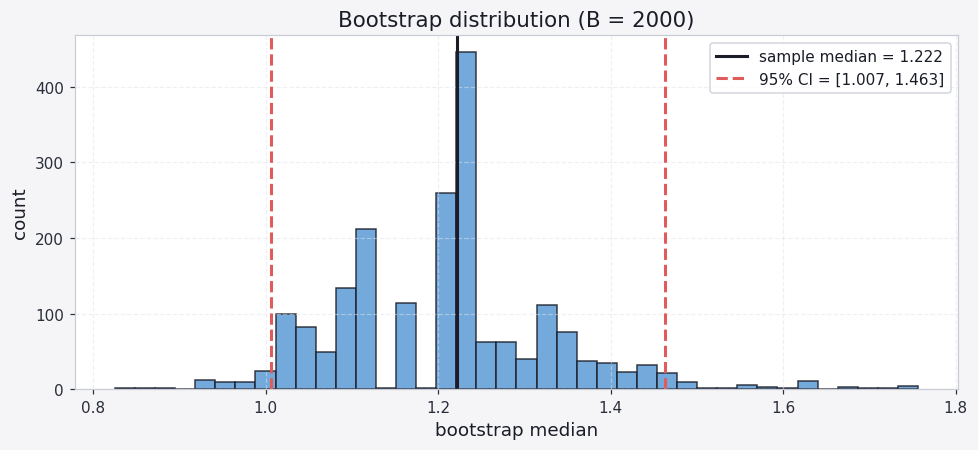

In [8]:
data = rng.exponential(scale=2.0, size=200)
B = 2000
medians = np.array([np.median(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])

ci_lo, ci_hi = np.percentile(medians, [2.5, 97.5])
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(medians, bins=40, color=PALETTE[0], edgecolor='#1a1d27', alpha=0.85)
ax.axvline(np.median(data), color='#1a1d27', lw=2, label=f'sample median = {np.median(data):.3f}')
ax.axvline(ci_lo, color=PALETTE[1], lw=2, ls='--', label=f'95% CI = [{ci_lo:.3f}, {ci_hi:.3f}]')
ax.axvline(ci_hi, color=PALETTE[1], lw=2, ls='--')
ax.set_xlabel('bootstrap median'); ax.set_ylabel('count')
ax.set_title(f'Bootstrap distribution (B = {B})')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


---
## What we just saw

- **Validation set** estimates of test MSE jiggle a lot from split to split — averaging over 20 splits stabilises them.
- **LOOCV** has zero variance from the choice of split (it uses all of them) but tends to have higher variance from the **correlation** between $n$ near-identical training sets.
- **5-fold CV** is the standard compromise — small bias, small variance, $5\times$ cost.
- The **bootstrap** doesn't need a parametric assumption; it gives you a CI for any function of the data.

> Lesson: never trust a single test split. CV is essentially free in compute compared with the cost of choosing the wrong model.
